# 🏥 Healthcare ML Platform
## Notebook 01 — Exploratory Data Analysis: Pima Indians Diabetes Dataset

**Dataset:** Pima Indians Diabetes Database (UCI / Kaggle)  
**Rows:** 768 patients  
**Goal:** Understand the data, find problems, and prepare it for the feature engineering pipeline.

### What this notebook covers
1. Loading and inspecting the raw data
2. Identifying hidden missing values (stored as zeros)
3. Visualising feature distributions
4. Analysing class balance
5. Exploring feature correlations
6. Saving the cleaned dataset

---
> **Note:** This is Module 2, Step 1 of the Healthcare ML Platform project.  
> All outputs are saved to `outputs/` for reference.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']==(10,5)
plt.rcParams['axes.titlesize']=13

---
## Step 1 — Load the Data

We load the raw CSV and do a first-pass inspection.  
Key things to check:
- **Shape** — how many rows and columns?
- **Column names** — are they meaningful?
- **Data types** — are numbers stored as numbers, not strings?

In [2]:
df = pd.read_csv(r"G:\healthcare\Dataset\raw\pima_diabetes.csv")

print(f"Shape   : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"nColumns :")
for col in df.columns:
    print(f" - {col}")

print(f"\nFirst 5 rows:")
df.head()

Shape   : 768 rows x 9 columns
nColumns :
 - Pregnancies
 - Glucose
 - BloodPressure
 - SkinThickness
 - Insulin
 - BMI
 - DiabetesPedigreeFunction
 - Age
 - Outcome

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---
## Step 2 — Statistical Summary


In [3]:


quant_vars = df.drop(columns=['Outcome'])
desc = pd.DataFrame({
    "Min": quant_vars.min(),
    "Max": quant_vars.max(),
    "Range": quant_vars.max() - quant_vars.min(),
    "Mean": quant_vars.mean(),
    "Median": quant_vars.median(),
    "Mode": quant_vars.mode().iloc[0],
    "Variance": quant_vars.var(),
    "Std_Dev": quant_vars.std(),
    
})
desc



,Min,Max,Range,Mean,Median,Mode,Variance,Std_Dev
Pregnancies,0.000,17.00,17.000,3.845052,3.0000,1.000,11.354056,3.369578
Glucose,0.000,199.00,199.000,120.894531,117.0000,99.000,1022.248314,31.972618
BloodPressure,0.000,122.00,122.000,69.105469,72.0000,70.000,374.647271,19.355807
SkinThickness,0.000,99.00,99.000,20.536458,23.0000,0.000,254.473245,15.952218
Insulin,0.000,846.00,846.000,79.799479,30.5000,0.000,13281.180078,115.244002
BMI,0.000,67.10,67.100,31.992578,32.0000,32.000,62.159984,7.884160
DiabetesPedigreeFunction,0.078,2.42,2.342,0.471876,0.3725,0.254,0.109779,0.331329
Age,21.000,81.00,60.000,33.240885,29.0000,22.000,138.303046,11.760232


**The Question arise from this summary:**

Can minimum value of below listed columns be zero (0)?</br>
=> On these columns, a value of zero does not make sense and thus indicates missing value.

Following columns or variables have an invalid zero value:

- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI </br>
It is better to replace zeros with nan since after that counting them would be easier and zeros need to be replaced with suitable values

---
## Step 3 — Exposing Hidden Missing Values

In this dataset, **zero is used as a placeholder for missing data** in 5 columns.  
We count how many zeros exist in each of these columns and calculate the percentage.

| Column | Problem |
|---|---|
| Glucose | Cannot be 0 in a living person |
| BloodPressure | Cannot be 0 in a living person |
| SkinThickness | 0 means "not measured" |
| Insulin | 0 means "not recorded" — almost 50% missing |
| BMI | Cannot be 0 in a living person |

**Fix:** Replace 0 → `NaN`, then impute with the column median.  
We use **median** (not mean) because medical data is often skewed.

In [4]:
# Replacing 0 with Nan
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[zero_cols]=df[zero_cols].replace(0,np.nan)


In [5]:
df_columns = df.columns

print(f"{'Column':<28} {'Nan Count':>10} {'% Missing':>10} {'Severity':>10}")
print('-'*65)

for col in df_columns:
    n= df[col].isnull().sum()
    pct= n/len(df) * 100
    severity = 'High' if pct > 20 else 'Midium' if pct>5 else 'Low' 

    print(f"{col:<28} {n:>10}   {pct:>8.1f}%  {severity:>5}")


Column                        Nan Count  % Missing   Severity
-----------------------------------------------------------------
Pregnancies                           0        0.0%    Low
Glucose                               5        0.7%    Low
BloodPressure                        35        4.6%    Low
SkinThickness                       227       29.6%   High
Insulin                             374       48.7%   High
BMI                                  11        1.4%    Low
DiabetesPedigreeFunction              0        0.0%    Low
Age                                   0        0.0%    Low
Outcome                               0        0.0%    Low


---
## Step 4 — Imputation with the column median

In [6]:
df_copy = df.copy()

df_copy['Glucose'].fillna(df_copy['Glucose'].mean(),inplace=True)
df_copy['BloodPressure'].fillna(df_copy['BloodPressure'].mean(),inplace=True)
df_copy['SkinThickness'].fillna(df_copy['SkinThickness'].mean(),inplace=True)
df_copy['Insulin'].fillna(df_copy['Insulin'].mean(),inplace=True)
df_copy['BMI'].fillna(df_copy['BMI'].mean(),inplace=True)

In [66]:
df_copy.to_csv('../Dataset/processed/pima_clean.csv',index=False)
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


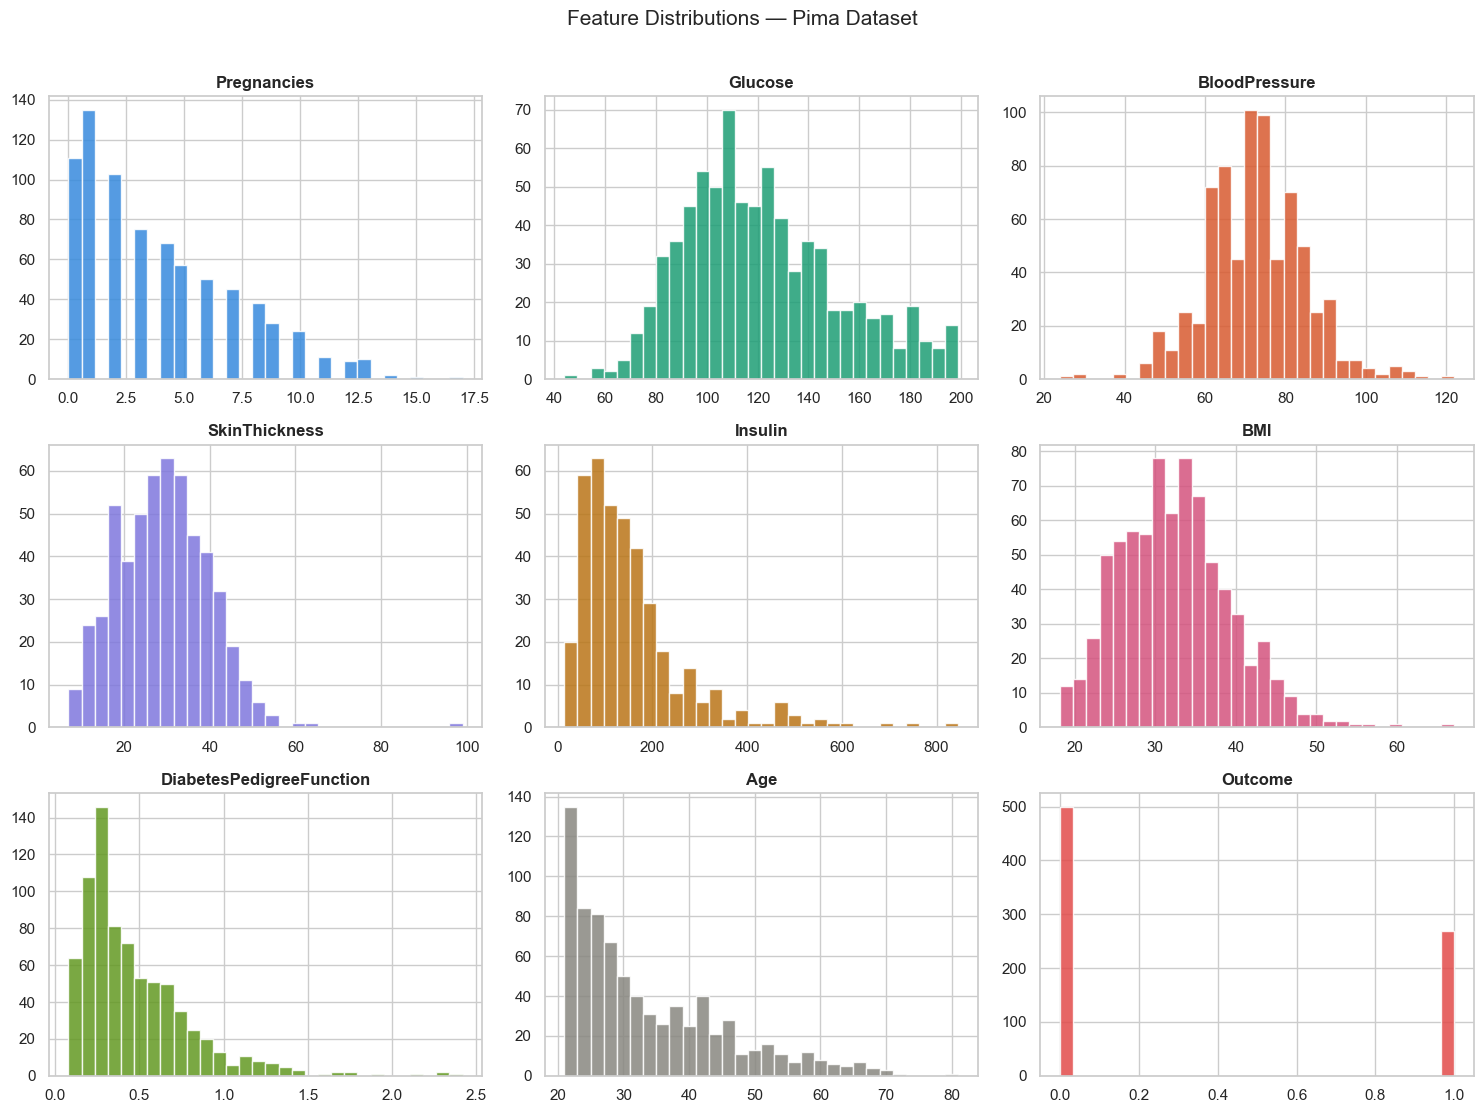

✓ Plot saved → outputs/pima_distributions.png


In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

colors = ['#378ADD','#1D9E75','#D85A30','#7F77DD',
          '#BA7517','#D4537E','#639922','#888780','#E24B4A']

for i, col in enumerate(df_copy.columns):
    axes[i].hist(df[col], bins=30, color=colors[i],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight='bold')

    

plt.suptitle('Feature Distributions — Pima Dataset', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/pima_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved → outputs/pima_distributions.png")

---
## Step 5 — Class Balance (Target Variable)

The target column `Outcome` tells us whether the patient was diagnosed with diabetes:
- `0` = No diabetes
- `1` = Diabetes

**Why this matters:**  
If the dataset is imbalanced (many more 0s than 1s), a model can cheat —  
it simply predicts "no diabetes" every time and still gets high accuracy.  
This is why we will use **ROC-AUC** as our main metric, not plain accuracy.

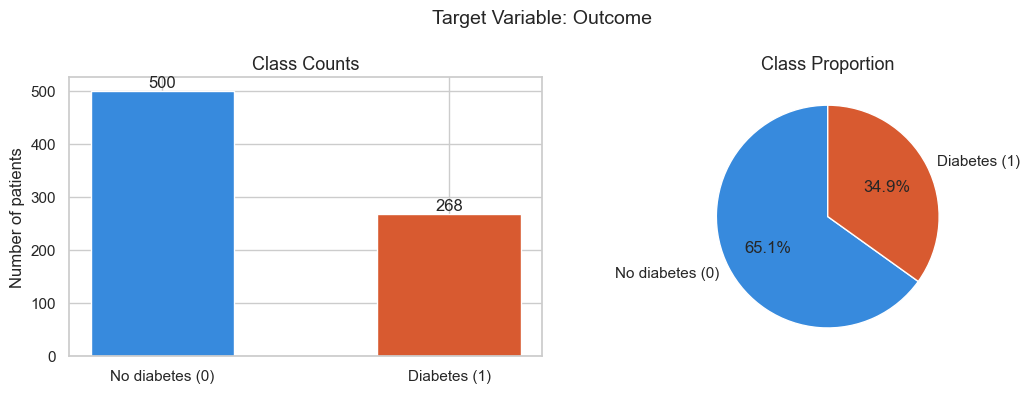

No diabetes : 500  (65.1%)
Diabetes    : 268  (34.9%)
Imbalance ratio : 1.87 : 1


In [27]:
counts = df_copy['Outcome'].value_counts()
labels = ['No diabetes (0)','Diabetes (1)']

fig,axes = plt.subplots(1,2,figsize=(11,4))

#Bar chart

bars= axes[0].bar(labels,counts.values,
                  color=['#378ADD','#D85A30'],
                  width=0.5,edgecolor='white')
axes[0].set_title('Class Counts')
axes[0].set_ylabel('Number of patients')

for bar,val in zip(bars,counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,val + 6,
                 str(val),ha='center',fontsize=12)
    
# Pie Chart

axes[1].pie(counts.values,labels=labels,
            colors=['#378ADD', '#D85A30'],
            autopct = '%1.1f%%',startangle=90,
            wedgeprops={'edgecolor':'white'})
axes[1].set_title('Class Proportion')

plt.suptitle("Target Variable: Outcome",fontsize= 14)
plt.tight_layout()
plt.savefig('../outputs/pima_class_balance.png')
plt.show()


print(f"No diabetes : {counts[0]}  ({counts[0]/len(df)*100:.1f}%)")
print(f"Diabetes    : {counts[1]}  ({counts[1]/len(df)*100:.1f}%)")
print(f"Imbalance ratio : {counts[0]/counts[1]:.2f} : 1")

---
## Step 6 — Correlation Heatmap

A correlation matrix shows how strongly each feature is related to every other feature.  
Values range from **-1** (perfect negative) to **+1** (perfect positive).  
We only show the lower triangle — the upper half is a mirror image.

**What to look for:**
- High correlation with `Outcome` → strong predictor
- High correlation between two features → they carry similar information (multicollinearity)

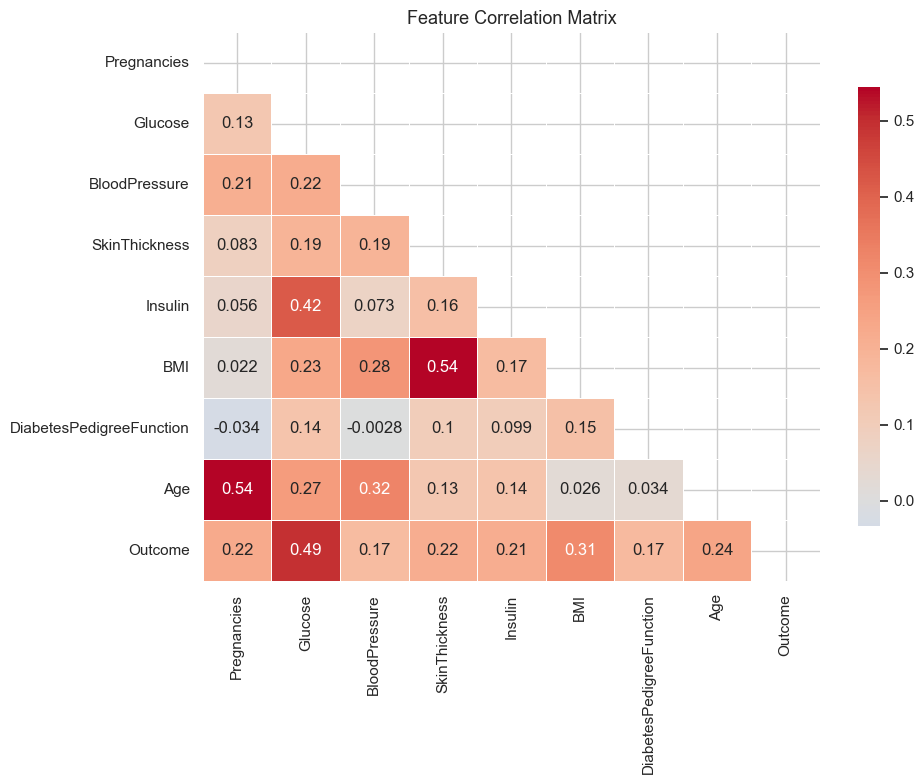

Top predictors of Outcome:
Outcome                     1.000000
Glucose                     0.492928
BMI                         0.311924
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.215299
Insulin                     0.214411
DiabetesPedigreeFunction    0.173844
BloodPressure               0.166074


In [31]:
plt.figure(figsize=(10,8))

corr= df_copy.corr()
mask = np.triu(np.ones_like(corr,dtype = bool))

sns.heatmap(corr,mask=mask,annot=True,cmap='coolwarm',center=0,
            linewidths=0.5,cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/pima_correlation.png',dpi=150)
plt.show()

print("Top predictors of Outcome:")
print(corr['Outcome'].sort_values(ascending=False).to_string())

---
## Step 7 — Feature vs Outcome (Boxplots)

Boxplots show the distribution of each feature split by the target class.  
If the two boxes are clearly separated → that feature is useful for prediction.  
If they overlap completely → the feature adds little predictive value.

The **orange line** inside each box is the median value.

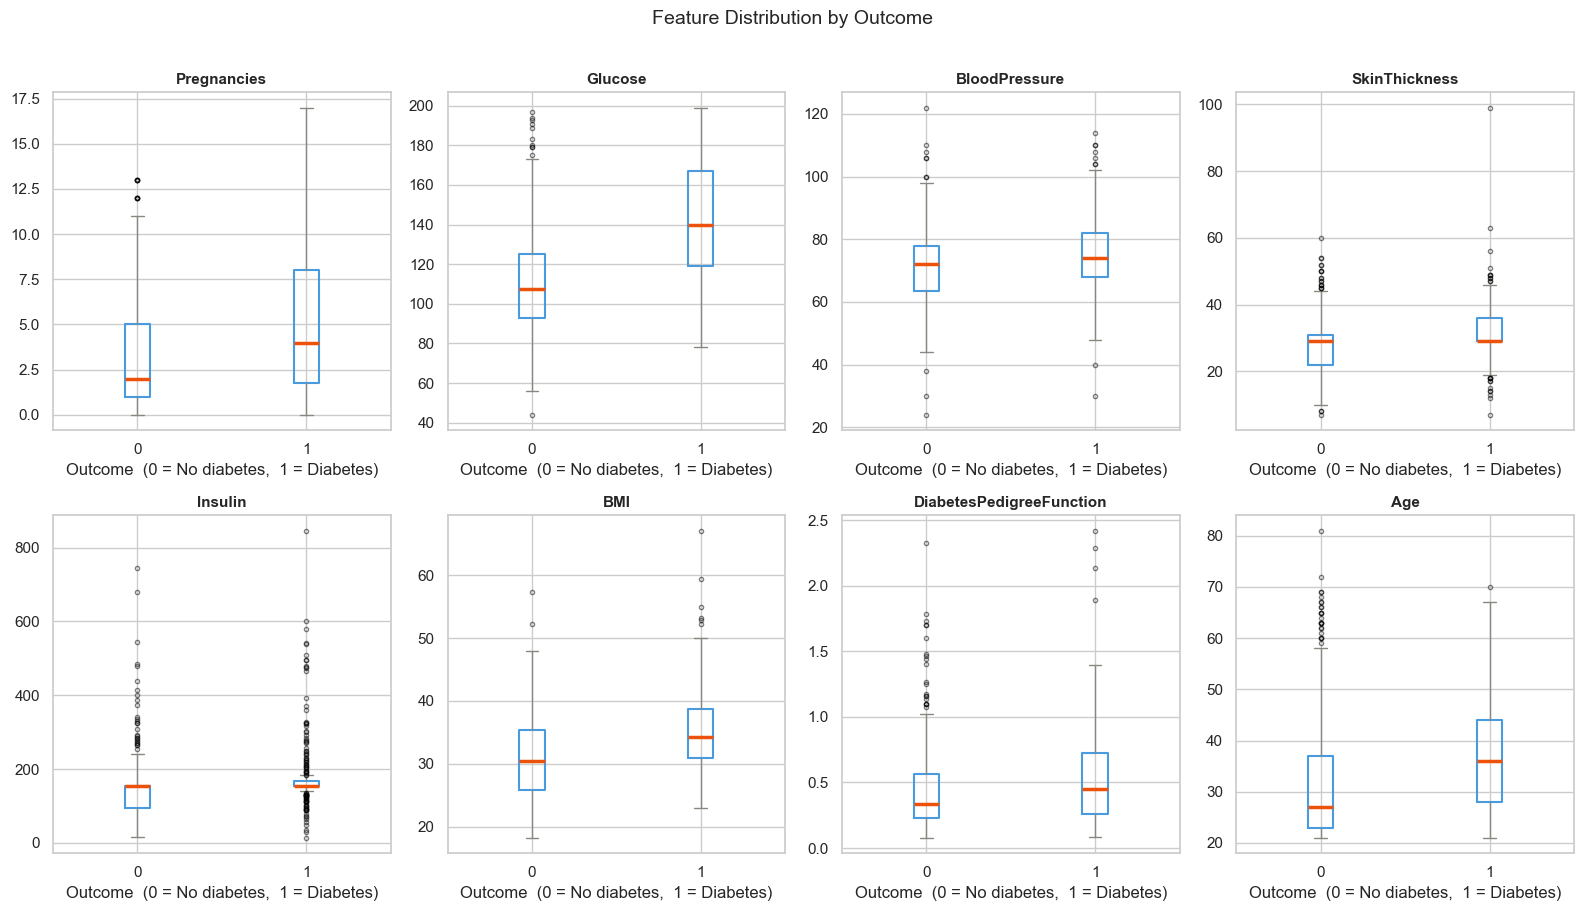

The gap between two groups in Glucose is significantly higher
Glucose is the strongest predictor of diabetes. 


In [65]:
feature_cols = [ c for c in df_copy.columns if c!='Outcome']

fig,axes = plt.subplots(2,4,figsize=(16,9))
axes = axes.flatten()

for i,col in enumerate(feature_cols):
    df_copy.boxplot(column=col,by='Outcome',ax=axes[i],
                    boxprops=dict(color="#499bdf", linewidth=1.5),
                    medianprops = dict(color="#EC520B", linewidth=2.5),
                    whiskerprops=dict(color="#888780"),
                    capprops=dict(color="#888780"),
                    flierprops=dict(color='#378ADD',marker='o',
                                    markersize=3,alpha =0.5))
    axes[i].set_title(col,fontsize=11,fontweight='bold')    
    axes[i].set_xlabel('Outcome  (0 = No diabetes,  1 = Diabetes)')

plt.suptitle('Feature Distribution by Outcome', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/pima_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


print("The gap between two groups in Glucose is significantly higher")
print("Glucose is the strongest predictor of diabetes. ")

---
## EDA Summary — Key Findings

| Finding | Detail |
|---|---|
| Dataset size | 768 rows × 9 columns |
| All numeric? | Yes — no encoding needed |
| Hidden missing values | 5 columns had zeros as placeholders |
| Worst missing column | Insulin — 48.7% were zeros |
| Fix applied | Replaced 0 → NaN → median imputation |
| Class balance | 65% No diabetes / 35% Diabetes |
| Strongest predictor | Glucose (correlation = 0.49 with Outcome) |
| Metric to use | ROC-AUC (not plain accuracy) |

### Outputs saved
- `outputs/pima_distributions.png`
- `outputs/pima_class_balance.png`
- `outputs/pima_correlation.png`
- `outputs/pima_boxplots.png`
- `data/processed/pima_clean.csv` 

---
**Next notebook → `02_EDA_diabetes130.ipynb`**